# 模块 04：反向传播

## 1. 理论背景
反向传播是在计算图上重复使用链式法则，高效求出每一层参数对最终损失的影响。

## 1.1 实际作用（用途）
- 让模型自动计算每个参数对损失的影响，是深度学习训练的基础。
- 支撑图像识别、语音识别、机器翻译、推荐系统和 LLM 等应用。
- 帮助排查梯度消失、梯度爆炸或某层参数无法学习的问题。

## 2. 数学推导
两层网络：$z_1=XW_1+b_1$，$a_1=\tanh(z_1)$，$z_2=a_1W_2+b_2$，$L=\frac{1}{n}\sum(z_2-y)^2$。

$$\frac{\partial L}{\partial z_2}=\frac{2}{n}(z_2-y)$$
$$\frac{\partial L}{\partial W_2}=a_1^T\frac{\partial L}{\partial z_2},\quad \frac{\partial L}{\partial W_1}=X^T\left((\frac{\partial L}{\partial z_2}W_2^T)\odot(1-a_1^2)\right)$$

## 3. 代码思路

本章代码把两层网络拆成前向和反向两部分：

1. 先构造小批量输入、目标值和两层网络参数，使所有矩阵形状都足够小，方便手算和检查。
2. `forward` 计算 `z1 -> a1 -> z2`，并把中间变量放进 `cache`，因为反向传播需要复用这些值。
3. `mse_loss` 只负责计算损失，保持损失函数和梯度计算逻辑分离。
4. `backward` 从输出层误差 `dz2` 开始，按链式法则依次求 `W2/b2`、隐藏层误差、`W1/b1` 的梯度。
5. 验证部分用 PyTorch autograd 对照每个参数梯度，确认手写反向传播的公式和形状都正确。

## 4. NumPy 实现

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)

# 小批量样本：5 个样本、3 维输入、2 维回归目标。
rng = np.random.default_rng(1)
X = rng.normal(size=(5, 3))
y = rng.normal(size=(5, 2))
params = {
    # W1/b1 是输入层到隐藏层参数，W2/b2 是隐藏层到输出层参数。
    'W1': rng.normal(scale=0.2, size=(3, 4)), 'b1': np.zeros(4),
    'W2': rng.normal(scale=0.2, size=(4, 2)), 'b2': np.zeros(2),
}

def forward(params, X):
    # 前向传播保留中间变量，反向传播会用它们计算梯度。
    z1 = X @ params['W1'] + params['b1']
    a1 = np.tanh(z1)
    z2 = a1 @ params['W2'] + params['b2']
    return z2, {'z1': z1, 'a1': a1, 'z2': z2}

def mse_loss(pred, y):
    return np.mean((pred - y) ** 2)

def backward(params, X, y, cache):
    # y.size 是所有输出元素数量，对应 mean 的归一化因子。
    n = y.size
    # 从损失对输出 z2 的梯度开始，逐层往前传。
    dz2 = 2 * (cache['z2'] - y) / n
    dW2 = cache['a1'].T @ dz2
    db2 = dz2.sum(axis=0)
    da1 = dz2 @ params['W2'].T
    # tanh'(z) = 1 - tanh(z)^2，这里 cache['a1'] 已经是 tanh(z1)。
    dz1 = da1 * (1 - cache['a1'] ** 2)
    dW1 = X.T @ dz1
    db1 = dz1.sum(axis=0)
    return {'W1': dW1, 'b1': db1, 'W2': dW2, 'b2': db2}

pred, cache = forward(params, X)
grads = backward(params, X, y, cache)
print('前向传播结果：当前 MSE 损失 =', mse_loss(pred, y), '；它衡量网络预测与目标值的平均平方误差。')
for name, g in grads.items(): print(f'反向传播梯度：参数 {name} 的梯度形状为 {g.shape}，L2 范数为 {np.linalg.norm(g):.6f}；范数反映该参数本轮更新强度。')


前向传播结果：当前 MSE 损失 = 1.1228685792256308 ；它衡量网络预测与目标值的平均平方误差。
反向传播梯度：参数 W1 的梯度形状为 (3, 4)，L2 范数为 0.193496；范数反映该参数本轮更新强度。
反向传播梯度：参数 b1 的梯度形状为 (4,)，L2 范数为 0.132297；范数反映该参数本轮更新强度。
反向传播梯度：参数 W2 的梯度形状为 (4, 2)，L2 范数为 0.097366；范数反映该参数本轮更新强度。
反向传播梯度：参数 b2 的梯度形状为 (2,)，L2 范数为 0.441393；范数反映该参数本轮更新强度。


## 5. 结果验证

In [2]:
try:
    import torch
    Xt = torch.tensor(X, dtype=torch.float64)
    yt = torch.tensor(y, dtype=torch.float64)
    # requires_grad=True 告诉 PyTorch 这些张量需要记录计算图并求梯度。
    torch_params = {k: torch.tensor(v, dtype=torch.float64, requires_grad=True) for k, v in params.items()}
    z1 = Xt @ torch_params['W1'] + torch_params['b1']
    a1 = torch.tanh(z1)
    z2 = a1 @ torch_params['W2'] + torch_params['b2']
    loss_t = torch.mean((z2 - yt) ** 2)
    loss_t.backward()
    # 对每个参数逐一比较手写梯度和 autograd 梯度。
    for k in grads:
        assert np.allclose(grads[k], torch_params[k].grad.numpy(), atol=1e-5), k
    print('验证通过：手写梯度与 PyTorch autograd 自动求导结果一致。')
except ImportError:
    print('提示：当前环境未安装 PyTorch；运行 `uv sync --all-groups` 后可运行本 cell 做 autograd 对照。')


验证通过：手写梯度与 PyTorch autograd 自动求导结果一致。


## 6. 可视化

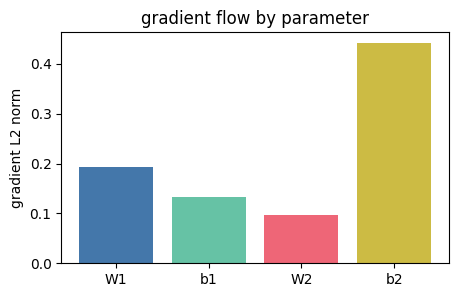

In [3]:
labels = list(grads.keys())
# 用梯度 L2 范数观察不同参数的更新强度是否同一量级。
values = [np.linalg.norm(grads[k]) for k in labels]
plt.figure(figsize=(5, 3))
plt.bar(labels, values, color=['#4477aa', '#66c2a5', '#ee6677', '#ccbb44'])
plt.ylabel('gradient L2 norm'); plt.title('gradient flow by parameter'); plt.show()
